In [74]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import torch
from scipy import signal

Read necessary files

In [75]:
data_cutoff=0 #Discard data from the beginning

free_space_0=pd.read_csv('../dvrk_si_col_9_1/train/free_space/joints/bag_50.csv')
free_space_0.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
free_space_1=pd.read_csv('../dvrk_si_col_9_1/train/free_space/joints/bag_51.csv')
free_space_1.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# free_space_2=pd.read_csv('CSV_Files/joints/Free_Space_2.csv')
# free_space_2.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']


sensor_data_0=pd.read_csv('../dvrk_si_col_9_1/test/sensor/interpolated_all_sensor_test.csv')
sensor_data_0.columns=['timestamps','x','y','z','t_x','t_y','t_z']
sensor_data_0 = sensor_data_0[data_cutoff:] 
sensor_data_0.index = pd.RangeIndex(len(sensor_data_0.index))

force_sensor_0=pd.read_csv('../dvrk_si_col_9_1/test/free_space/joints/interpolated_all_joints.csv')
force_sensor_0.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
force_sensor_0 = force_sensor_0[data_cutoff:]
force_sensor_0.index = pd.RangeIndex(len(force_sensor_0.index))

jacobian_read = np.loadtxt('../dvrk_si_col_9_1/test/free_space/jacobian/interpolated_all_jacobian.csv', delimiter=',')
jacobian = jacobian_read[:,1:].astype('float32')
jacobian = jacobian

In [76]:
sensor_data_0

,timestamps,x,y,z,t_x,t_y,t_z
0,0.005,-0.007954,-0.012507,-0.000266,-0.000235,-0.000293,-0.000100
1,0.010,-0.009763,-0.018842,0.001865,-0.000441,-0.000355,0.000165
2,0.015,-0.009961,-0.017326,0.004936,-0.000214,0.000107,0.000064
3,0.020,-0.009018,-0.018178,0.002335,-0.000165,-0.000061,-0.000025
4,0.025,-0.007021,-0.017581,0.007704,-0.000416,-0.000232,-0.000088
...,...,...,...,...,...,...,...
29332,146.665,-0.233081,-0.255822,0.024282,-0.002417,-0.002428,-0.001510
29333,146.670,-0.235465,-0.253929,0.019852,-0.002416,-0.002565,-0.001417
29334,146.675,-0.233686,-0.254588,0.023439,-0.002281,-0.002418,-0.001211
29335,146.680,-0.233698,-0.251973,0.020478,-0.002251,-0.002258,-0.001494


Create lookup table with freespace data

In [77]:
lookup_table = pd.concat(
    # [free_space_0,free_space_1,free_space_2], ignore_index=True)
    [free_space_0,free_space_1], ignore_index=True)
lookup_table.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
print(lookup_table)

       timestamps     j1pos     j2pos     j3pos     j4pos     j5pos     j6pos  \
0        0.010046 -0.213764 -0.781012  0.128006  1.097367  0.072780 -0.178314   
1        0.020050 -0.213764 -0.781012  0.128006  1.097367  0.072780 -0.178314   
2        0.030180 -0.213764 -0.781012  0.128006  1.097367  0.072780 -0.178314   
3        0.040318 -0.213764 -0.781012  0.128006  1.097367  0.072780 -0.178314   
4        0.050271 -0.213764 -0.781012  0.128006  1.097367  0.072780 -0.178314   
...           ...       ...       ...       ...       ...       ...       ...   
91297  560.628985 -0.104022 -0.926681  0.135332 -0.075907  0.256208 -0.042320   
91298  560.639058 -0.104022 -0.926681  0.135332 -0.075907  0.256208 -0.042320   
91299  560.649106 -0.104022 -0.926681  0.135332 -0.075907  0.256208 -0.042320   
91300  560.659082 -0.104022 -0.926681  0.135332 -0.075907  0.256208 -0.042320   
91301  560.669163 -0.104022 -0.926681  0.135332 -0.075907  0.256208 -0.042320   

              j1vel  j2vel 

RMSE

In [78]:
def RMSE(y_predicted,y):
    return math.sqrt(np.square(np.subtract(y,y_predicted)).mean())

Simple multiplication

In [79]:
efforts=[]
for i in range(1,7):
    efforts.append(force_sensor_0['j'+str(i)+'eff'])
eff= np.transpose(efforts)
#jacobian = jacobian.numpy()
force = torch.zeros((eff.shape[0], 6))
eff_t = torch.from_numpy(eff.astype('float32'))
for i in range(eff.shape[0]):
    j = jacobian[i,:].reshape(6,6)
    jacobian_inv_t = torch.from_numpy(np.linalg.inv(j).transpose())
    force[i,:] = torch.matmul(jacobian_inv_t, eff_t[i,:])
force_np = force.numpy()

# Define the file path where you want to save the CSV file
file_path = "simple_mtply_si.csv"

# Save the NumPy matrix as a CSV file
np.savetxt(file_path, force_np, delimiter=',', fmt='%d')

In [80]:
force_np

array([[-13.148542  , -27.329659  , -16.276308  ,  -3.6096513 ,
          0.8870151 ,   1.012362  ],
       [-13.154468  , -27.328032  , -16.277533  ,  -3.609631  ,
          0.8875101 ,   1.0128224 ],
       [-13.148187  , -27.328482  , -16.275293  ,  -3.60965   ,
          0.88703084,   1.0123905 ],
       ...,
       [  3.05518   , -29.92667   , -21.845493  ,  -5.7532716 ,
         -0.8779103 ,   0.39582038],
       [  3.3559806 , -29.688423  , -21.59048   ,  -5.6975417 ,
         -0.9071244 ,   0.3590249 ],
       [  3.6305306 , -29.557076  , -21.394962  ,  -5.6596804 ,
         -0.9347408 ,   0.32712272]], dtype=float32)

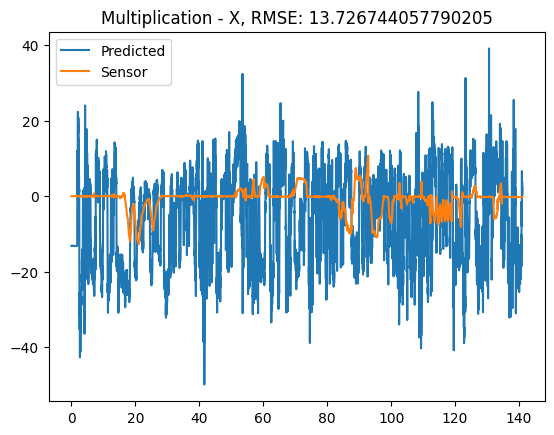

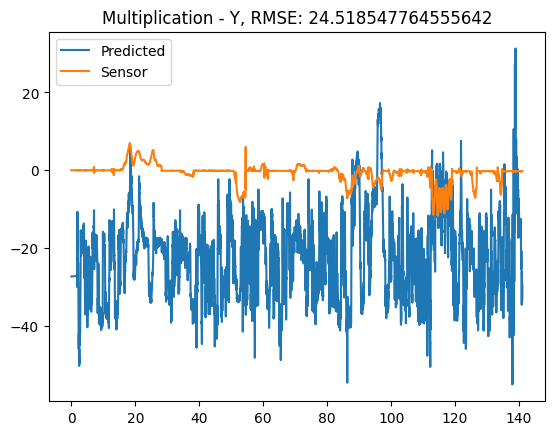

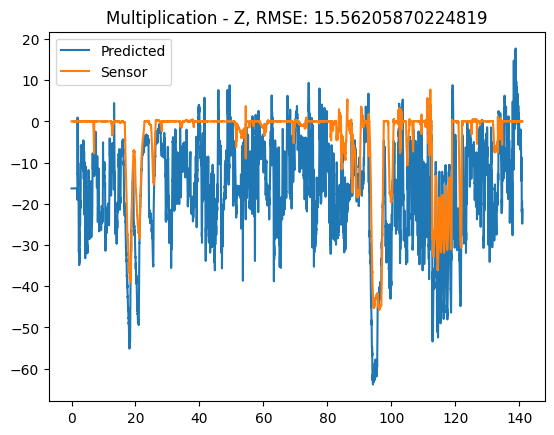

In [81]:
plt.plot(force_sensor_0['timestamps'],force_np[:,0], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['x'][0:len(force_np[:,0])], label='Sensor')
plt.legend()
plt.title('Multiplication - X, RMSE: '+str(RMSE(force_np[:,0],sensor_data_0['x'][0:len(force_np[:,0])])))
plt.savefig('Multiplication-X.png')
plt.show()
plt.plot(force_sensor_0['timestamps'],force_np[:,1], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['y'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Multiplication - Y, RMSE: '+str(RMSE(force_np[:,1],sensor_data_0['y'][0:len(force_np[:,1])])))
plt.savefig('Multiplication-Y.png')
plt.show()
plt.plot(force_sensor_0['timestamps'],force_np[:,2], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['z'][0:len(force_np[:,2])], label='Sensor')
plt.legend()
plt.title('Multiplication - Z, RMSE: '+str(RMSE(force_np[:,2],sensor_data_0['z'][0:len(force_np[:,2])])))
plt.savefig('Multiplication-Z.png')
plt.show()

Zero Velocity Baseline

In [82]:
base_table = lookup_table.loc[(abs(lookup_table['j1vel']) < 0.00003) & (abs(lookup_table['j2vel']) < 0.00003) & (abs(lookup_table['j3vel']) < 0.00003) & (abs(lookup_table['j4vel']) < 0.00003) & (abs(lookup_table['j5vel']) < 0.00003) & (abs(lookup_table['j6vel']) < 0.00003) ]

In [83]:
baselines={}
for i in range(6):
    baselines['base_'+str(i+1)]= np.mean(base_table['j'+str(i+1)+'eff'])

In [84]:
baselines

{'base_1': -0.657143707288051,
 'base_2': 3.789616661742436,
 'base_3': -6.161595363093828,
 'base_4': -0.0021118644283421245,
 'base_5': 0.016208590267814557,
 'base_6': 0.01888728570864031}

In [85]:
efforts=[]
angle = 3.1415926/2
Ra = torch.from_numpy(np.array([[np.cos(angle), -np.sin(angle), 0.0], [np.sin(angle), np.cos(angle), 0.0], [0.0, 0.0, 1.0]]).astype('float32'))
Rz = torch.from_numpy(np.matrix([[-1.0000, 0.0, 0.0], [0.0, -0.7071, -0.7071], [0.0, -0.7071, 0.7071]]).astype('float32'))
for i in range(1,7):
    efforts.append(force_sensor_0['j'+str(i)+'eff']-baselines['base_'+str(i)])
eff= np.transpose(efforts)
force = torch.zeros((eff.shape[0], 6))
eff_t = torch.from_numpy(eff.astype('float32'))
for i in range(eff.shape[0]):
    j = jacobian[i,:].reshape(6,6)
    jacobian_inv_t = torch.from_numpy(np.linalg.inv(j).transpose())
    force[i,:] = torch.matmul(jacobian_inv_t, eff_t[i,:])
    force[i,0:3] = torch.matmul(Ra, torch.matmul(Rz, force[i,0:3]))
force_np = force.numpy()

# Define the file path where you want to save the CSV file
file_path = "zero_v_si.csv"

# Save the NumPy matrix as a CSV file
np.savetxt(file_path, force_np, delimiter=',', fmt='%.4f')

In [86]:
force_np

array([[  1.0114372 ,   3.1424012 ,   0.66925   ,   0.14853467,
          0.2298714 ,   0.21394005],
       [  1.01172   ,   3.1483278 ,   0.66723263,   0.1485549 ,
          0.23036641,   0.21440047],
       [  1.0129877 ,   3.142045  ,   0.66913664,   0.14853592,
          0.22988711,   0.21396856],
       ...,
       [-13.624206  , -11.660475  ,  -3.240365  ,  -2.1506255 ,
         -1.5350541 ,  -0.9117547 ],
       [-13.2892475 , -11.944139  ,  -3.2483306 ,  -2.0941453 ,
         -1.5642681 ,  -0.9459671 ],
       [-13.072823  , -12.2003145 ,  -3.2238464 ,  -2.0554726 ,
         -1.5918845 ,  -0.975086  ]], dtype=float32)

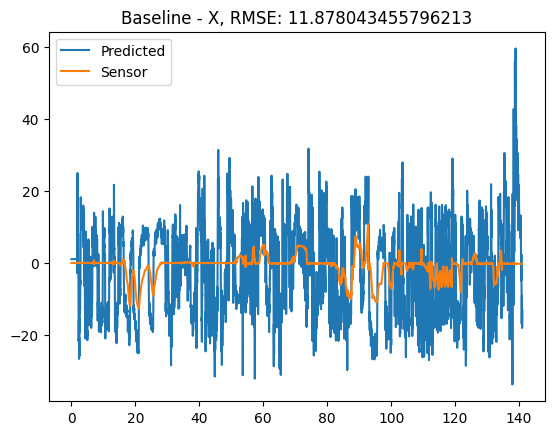

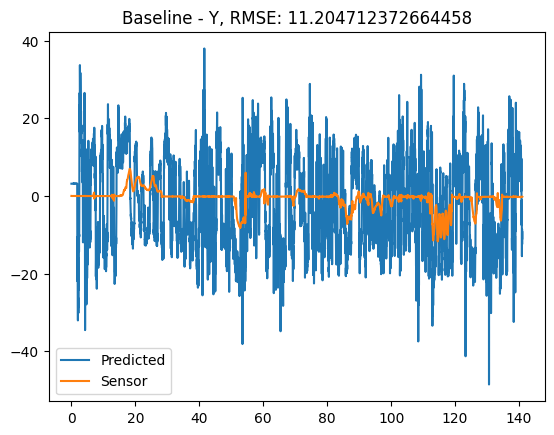

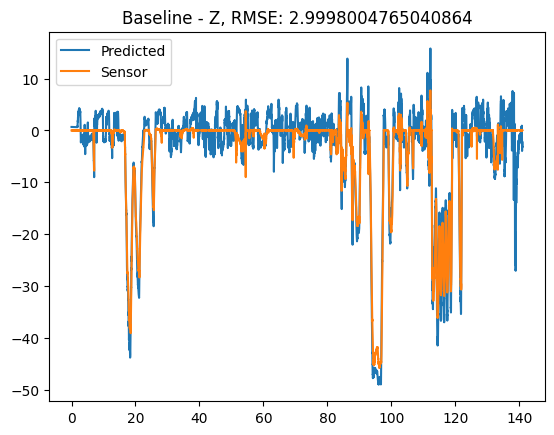

In [87]:
plt.plot(force_sensor_0['timestamps'],force_np[:,0], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['x'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Baseline - X, RMSE: '+str(RMSE(force_np[:,0],sensor_data_0['x'][0:len(force_np[:,1])])))
plt.savefig('Zero_Vel-X.png')
plt.show()
plt.plot(force_sensor_0['timestamps'],force_np[:,1], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['y'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Baseline - Y, RMSE: '+str(RMSE(force_np[:,1],sensor_data_0['y'][0:len(force_np[:,1])])))
plt.savefig('Zero_Vel-Y.png')
plt.show()
plt.plot(force_sensor_0['timestamps'],force_np[:,2], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['z'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Baseline - Z, RMSE: '+str(RMSE(force_np[:,2],sensor_data_0['z'][0:len(force_np[:,1])])))
plt.savefig('Zero_Vel-Z.png')
plt.show()

Vector Search

In [88]:
lookup_table_np = lookup_table[lookup_table.columns[1:13]].to_numpy()
np.shape(lookup_table_np)

(91302, 12)

In [89]:
d = 12
nb = np.shape(lookup_table_np)[0]
nq = 1
import faiss                   # make faiss available
index = faiss.IndexFlatL2(d)   # build the index
print(index.is_trained)
index.add(lookup_table_np)                  # add vectors to the index
print(index.ntotal)

True
91302


In [90]:
force_sensor_0_np = force_sensor_0[force_sensor_0.columns[1:13]].to_numpy()
k = 1
D, I = index.search(np.array([force_sensor_0_np[0]]), k)  
print(I[0][0])

1601


In [91]:
efforts = []
base_arr = []
for i in range(len(force_sensor_0)):
    D, I = index.search(np.array([force_sensor_0_np[i]]), k)  
    base = lookup_table.loc[I[0][0]][lookup_table.columns[13:]]
    base_arr.append(base)
    efforts.append(force_sensor_0.loc[i][force_sensor_0.columns[13:]]-base)
efforts=np.array(efforts)
import torch
#jacobian = jacobian.numpy()
force = torch.zeros((efforts.shape[0], 6))
eff_t = torch.from_numpy(efforts.astype('float32'))
for i in range(efforts.shape[0]):
    j = jacobian[i,:].reshape(6,6)
    jacobian_inv_t = torch.from_numpy(np.linalg.inv(j).transpose())
    force[i,:] = torch.matmul(jacobian_inv_t, eff_t[i,:])
    force[i,0:3] = torch.matmul(Ra, torch.matmul(Rz, force[i,0:3]))
force_np = force.numpy()

# Define the file path where you want to save the CSV file
file_path = "force_np_si.csv"
file_path_a = "sensor_data_0_si.csv"

# Save the NumPy matrix as a CSV file
np.savetxt(file_path, force_np, delimiter=',', fmt='%d')
np.savetxt(file_path_a, sensor_data_0, delimiter=',', fmt='%d')

In [92]:
force_np

array([[-10.398132  ,   1.87861   ,   3.0694528 ,  -1.2257581 ,
          0.07695787,   0.12622732],
       [-10.39785   ,   1.8845364 ,   3.0674348 ,  -1.2257378 ,
          0.07745287,   0.12668774],
       [-10.396582  ,   1.8782536 ,   3.0693402 ,  -1.2257568 ,
          0.07697358,   0.12625583],
       ...,
       [  3.1278856 ,   1.648376  ,  -7.5271587 ,   0.43895513,
          0.14720063,   0.04672653],
       [  3.4440236 ,   1.3514122 ,  -7.556085  ,   0.49446642,
          0.11798658,   0.01062359],
       [  3.6403503 ,   1.0813477 ,  -7.553897  ,   0.5321043 ,
          0.09037018,  -0.02046001]], dtype=float32)

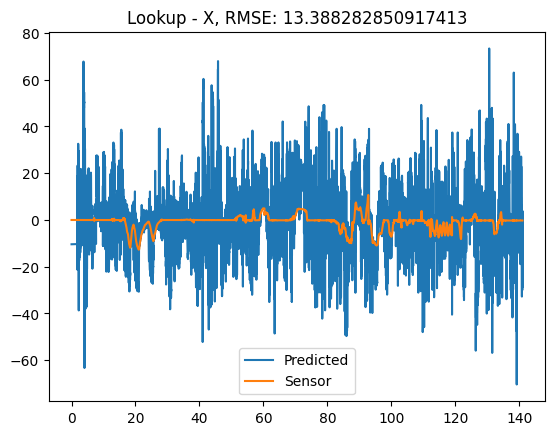

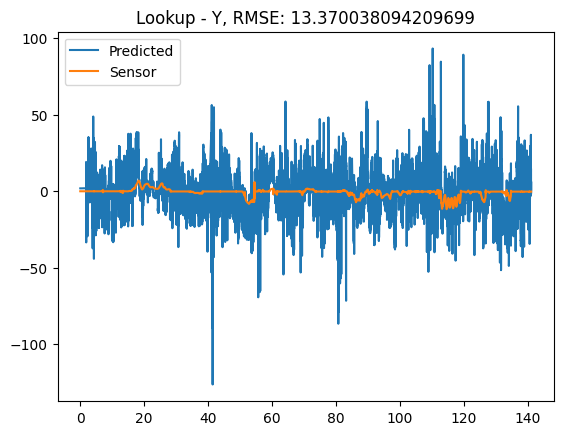

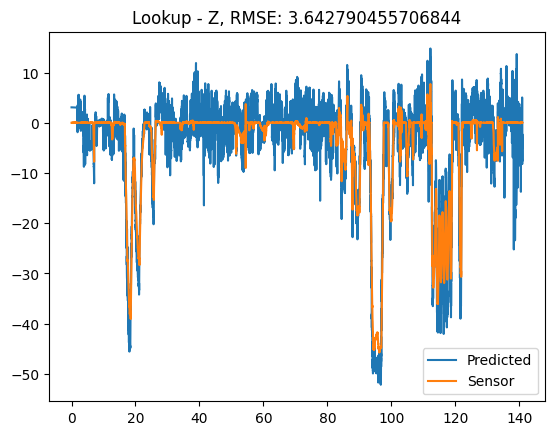

In [93]:
plt.plot(force_sensor_0['timestamps'],force_np[:,0], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['x'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Lookup - X, RMSE: '+str(RMSE(force_np[:,0],sensor_data_0['x'][0:len(force_np[:,1])])))
plt.show()
plt.plot(force_sensor_0['timestamps'],force_np[:,1], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['y'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Lookup - Y, RMSE: '+str(RMSE(force_np[:,1],sensor_data_0['y'][0:len(force_np[:,1])])))
plt.show()
plt.plot(force_sensor_0['timestamps'],force_np[:,2], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['z'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Lookup - Z, RMSE: '+str(RMSE(force_np[:,2],sensor_data_0['z'][0:len(force_np[:,1])])))
plt.show()

Filtered Lookup Table

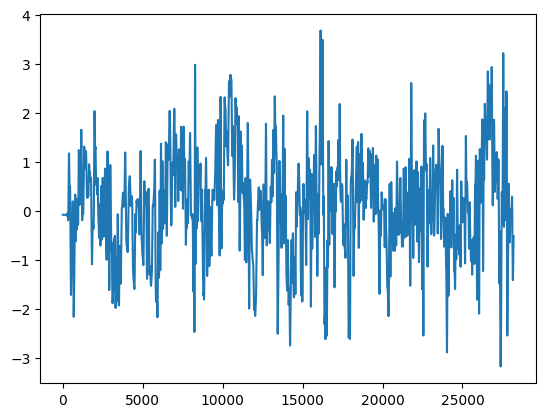

In [94]:
fs = 2000
fc = 30  # Cut-off frequency of the filter
w = fc / (fs / 2) # Normalize the frequency
b, a = signal.butter(5, w, 'low')
output = signal.filtfilt(b, a, efforts[:,0])
plt.plot(output)
plt.show()

In [95]:
efforts_f = np.zeros_like(efforts)
for i in range(6):
    efforts_f[:,i] = signal.filtfilt(b, a, efforts[:,i])

In [96]:
force = torch.zeros((efforts.shape[0], 6))
eff_t = torch.from_numpy(efforts_f.astype('float32'))
for i in range(efforts.shape[0]):
    j = jacobian[i,:].reshape(6,6)
    jacobian_inv_t = torch.from_numpy(np.linalg.inv(j).transpose())
    force[i,:] = torch.matmul(jacobian_inv_t, eff_t[i,:])
    force[i,0:3] = torch.matmul(Ra, torch.matmul(Rz, force[i,0:3]))
force_np = force.numpy()

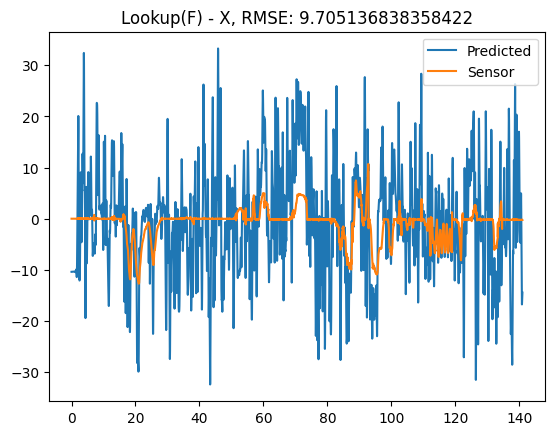

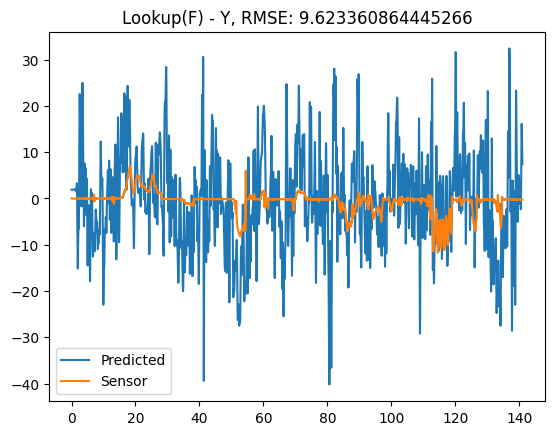

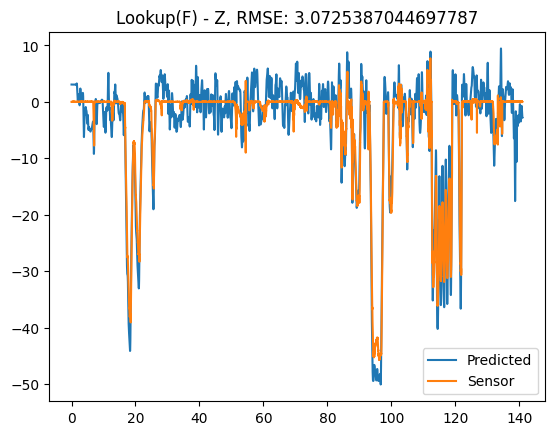

In [97]:
plt.plot(force_sensor_0['timestamps'],force_np[:,0], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['x'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Lookup(F) - X, RMSE: '+str(RMSE(force_np[:,0],sensor_data_0['x'][0:len(force_np[:,1])])))
plt.savefig('Lookup-X.png')
plt.show()
plt.plot(force_sensor_0['timestamps'],force_np[:,1], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['y'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Lookup(F) - Y, RMSE: '+str(RMSE(force_np[:,1],sensor_data_0['y'][0:len(force_np[:,1])])))
plt.savefig('Lookup-Y.png')
plt.show()
plt.plot(force_sensor_0['timestamps'],force_np[:,2], label='Predicted')
plt.plot(force_sensor_0['timestamps'],sensor_data_0['z'][0:len(force_np[:,1])], label='Sensor')
plt.legend()
plt.title('Lookup(F) - Z, RMSE: '+str(RMSE(force_np[:,2],sensor_data_0['z'][0:len(force_np[:,1])])))
plt.savefig('Lookup-Z.png')
plt.show()